# Parking Lot Occupancy Prediction — Sprint 1 (Baseline + Reproducible Pipeline)

This notebook implements **User Stories #4–#7** end-to-end:

- **US#4** Collect / validate raw historical parking data (CSV ingestion + schema checks + daily quality report)
- **US#5** Transform raw data into ML-ready form (timezone handling, resampling at 1/5/15-min, missing handling)
- **US#6** Feature engineering (temporal + lag + trend), with **leakage-safe target alignment**
- **US#7** Train and evaluate an **interpretable Decision Tree baseline** using a **time-aware split**, record metrics, and extract decision rules.

> **Reproducibility:** We fix random seeds, keep functions deterministic, and log all key choices (frequency, ETA horizon, thresholding strategy, model hyperparameters).



In [1]:
# ---- Setup (reproducibility + imports) ----
import os
import numpy as np
import pandas as pd
from IPython.display import display

from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional

# sklearn baseline models + metrics
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# Optional: plotting (keep it minimal and reproducible)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

CSV_PATH = "Paid_Parking_Occupancy_(Last_30_Days)_20260223.csv"  # update if needed


## User Story #4 — Data collection + raw validation (CSV ingestion)

Acceptance Criteria mapping:

- **AC#1 (US#4):** raw data is collected for all target garages/lots (we ingest the entire CSV; later we aggregate to lot_id)
- **AC#2:** stored as immutable raw format with timestamps preserved (we read the CSV as-is; you can keep the raw file unchanged)
- **AC#3:** dataset includes a lot identifier, timestamp, and occupancy fields (we validate required columns and compute `occupancy_rate`)
- **AC#4:** accessible programmatically (all steps are pure Python functions; file I/O via pandas)

We'll implement:
1) `load_raw_csv()`  
2) `validate_raw_schema()`  
3) `daily_quality_report()`  


In [2]:
def load_raw_csv(csv_path: str) -> pd.DataFrame:
    """Load raw CSV with minimal assumptions. Keep it immutable (no in-place edits)."""
    df = pd.read_csv(csv_path, low_memory=False)  # low_memory=False avoids mixed dtype surprises
    return df

REQUIRED_RAW_COLS = [
    "OccupancyDateTime",
    "PaidOccupancy",
    "ParkingSpaceCount",
    "SourceElementKey",
    "PaidParkingArea",
]

def validate_raw_schema(df_raw: pd.DataFrame, required_cols: List[str] = REQUIRED_RAW_COLS) -> None:
    """Raise an error early if the raw feed doesn't have what downstream needs."""
    missing = [c for c in required_cols if c not in df_raw.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

def clean_and_standardize(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Clean types, drop invalid rows, and compute occupancy_rate.

    Notes:
    - We keep timestamps as provided, but convert to pandas datetime.
    - We clip PaidOccupancy to [0, ParkingSpaceCount] for physical consistency.
    - We dedupe exact (SourceElementKey, timestamp) collisions by mean occupancy_rate.
    """
    df = df_raw.copy()

    # Parse datetime
    df["OccupancyDateTime"] = pd.to_datetime(df["OccupancyDateTime"], errors="coerce")
    df = df.dropna(subset=["OccupancyDateTime"]).copy()

    # Numeric parsing
    for c in ["PaidOccupancy", "ParkingSpaceCount"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["PaidOccupancy", "ParkingSpaceCount", "SourceElementKey", "PaidParkingArea"]).copy()
    df = df[df["ParkingSpaceCount"] > 0].copy()
    df = df[df["PaidOccupancy"] >= 0].copy()

    # Physical clipping
    df["PaidOccupancy"] = df["PaidOccupancy"].clip(lower=0, upper=df["ParkingSpaceCount"])
    df["occupancy_rate"] = df["PaidOccupancy"] / df["ParkingSpaceCount"]

    # Dedupe identical timestamps per stall/key
    keep_meta = [c for c in ["PaidParkingArea", "BlockfaceName", "SideOfStreet", "ParkingTimeLimitCategory"] if c in df.columns]

    agg_dict = {
        "occupancy_rate": "mean",
        "PaidOccupancy": "mean",
        "ParkingSpaceCount": "max",
        "PaidParkingArea": "first",
    }
    for c in keep_meta:
        agg_dict[c] = "first"

    df = (
        df.sort_values("OccupancyDateTime")
          .groupby(["SourceElementKey", "OccupancyDateTime"], as_index=False)
          .agg(agg_dict)
    )
    return df

def daily_quality_report(df_clean: pd.DataFrame) -> pd.DataFrame:
    """A simple daily quality report to check completeness/health.

    Outputs:
    - number of readings
    - number of unique stalls (SourceElementKey)
    - mean occupancy_rate, % missing occupancy_rate
    """
    d = df_clean.copy()
    d["date"] = d["OccupancyDateTime"].dt.date

    rep = (
        d.groupby("date")
         .agg(
             rows=("occupancy_rate", "size"),
             unique_stalls=("SourceElementKey", "nunique"),
             mean_occ=("occupancy_rate", "mean"),
             pct_missing_occ=("occupancy_rate", lambda s: float(s.isna().mean()))
         )
         .reset_index()
    )
    return rep

# ---- Run US#4 ingestion + checks ----
df_raw = load_raw_csv(CSV_PATH)
validate_raw_schema(df_raw)
df_clean = clean_and_standardize(df_raw)

print("Raw shape:", df_raw.shape)
print("Clean shape:", df_clean.shape)
display(daily_quality_report(df_clean).head(10))


Raw shape: (25547864, 12)
Clean shape: (25542864, 9)


,date,rows,unique_stalls,mean_occ,pct_missing_occ
0,2026-01-16,623674,1441,0.336227,0.0
1,2026-01-17,1003390,1410,0.343306,0.0
2,2026-01-20,998028,1438,0.291023,0.0
3,2026-01-21,1001111,1440,0.305026,0.0
4,2026-01-22,992114,1430,0.297637,0.0
5,2026-01-23,1000216,1440,0.327787,0.0
6,2026-01-24,1005195,1414,0.346074,0.0
7,2026-01-26,989524,1428,0.285492,0.0
8,2026-01-27,996564,1434,0.304145,0.0
9,2026-01-28,989469,1427,0.297245,0.0


## User Story #5 — Transform to ML-ready schema (uniform resampling)

Key idea: We decided to model **per lot_id** (e.g., `PaidParkingArea`), not per stall.

Pipeline:
1. **Resample per stall** to a uniform grid (1/5/15-min) so that all stalls align in time.
2. **Aggregate stalls → lot** using capacity-weighted occupancy.
3. Output ML-ready schema: `(lot_id, timestamp, lot_capacity, lot_occupied, occupancy_rate)`.

Acceptance Criteria mapping:

- **AC#1:** uniformly sampled at agreed granularity (freq)
- **AC#2:** missing handled consistently (interpolate within a limit, then ffill/bfill)
- **AC#3:** pipeline reproducible (pure functions + deterministic operations)
- **AC#4:** result can be loaded directly by ML code (no extra preprocessing)



In [7]:
def resample_per_stall(df_clean: pd.DataFrame, freq: str, interp_limit_bins: int = 8) -> pd.DataFrame:
    """Resample each SourceElementKey to a fixed time grid.

    Missing handling:
    - interpolate small gaps (up to interp_limit_bins)
    - then forward/back-fill to ensure a dense series per key
    """
    def one_key(g: pd.DataFrame) -> pd.DataFrame:
        g = g.set_index("OccupancyDateTime").sort_index()

        meta = {
            "SourceElementKey": g["SourceElementKey"].iloc[0],
            "ParkingSpaceCount": float(g["ParkingSpaceCount"].max()),
            "PaidParkingArea": g["PaidParkingArea"].iloc[0],
        }

        out = g[["occupancy_rate"]].resample(freq).mean()

        out["occupancy_rate"] = out["occupancy_rate"].interpolate(limit=interp_limit_bins)
        out["occupancy_rate"] = out["occupancy_rate"].ffill().bfill()

        for k, v in meta.items():
            out[k] = v

        return out.reset_index()

    rs = (
        df_clean.groupby("SourceElementKey", group_keys=False)
                .apply(one_key)
                .reset_index(drop=True)
    )
    return rs

def aggregate_to_lot(df_rs: pd.DataFrame) -> pd.DataFrame:
    """Aggregate stall-level series to lot-level series (PaidParkingArea).

    We estimate occupied spaces per stall as:
        occupied_est = occupancy_rate * ParkingSpaceCount

    Then sum across stalls within each lot and timestamp.
    """
    d = df_rs.copy()
    d["lot_id"] = d["PaidParkingArea"].astype(str)
    d["occupied_est"] = d["occupancy_rate"] * d["ParkingSpaceCount"]

    lot = (
        d.groupby(["lot_id", "OccupancyDateTime"], as_index=False)
         .agg(
             lot_capacity=("ParkingSpaceCount", "sum"),
             lot_occupied=("occupied_est", "sum"),
         )
    )
    lot["occupancy_rate"] = lot["lot_occupied"] / lot["lot_capacity"]
    return lot

# ---- Build ML-ready lot dataset at 15 min ----
FREQ = "15min"
df_rs = resample_per_stall(df_clean, freq=FREQ, interp_limit_bins=8)
df_lot = aggregate_to_lot(df_rs)

print("Resampled stall-level:", df_rs.shape, "unique stalls:", df_rs["SourceElementKey"].nunique())
print("Lot-level:", df_lot.shape, "unique lots:", df_lot["lot_id"].nunique())
display(df_lot.head())


Resampled stall-level: (4573391, 5) unique stalls: 1487
Lot-level: (68250, 5) unique lots: 22


,lot_id,OccupancyDateTime,lot_capacity,lot_occupied,occupancy_rate
0,12th Avenue,2026-01-16 12:15:00,69.0,21.550000,0.312319
1,12th Avenue,2026-01-16 12:30:00,69.0,20.866667,0.302415
2,12th Avenue,2026-01-16 12:45:00,69.0,21.866667,0.316908
3,12th Avenue,2026-01-16 13:00:00,69.0,19.400000,0.281159
4,12th Avenue,2026-01-16 13:15:00,69.0,20.066667,0.290821


## User Story #6 — Feature engineering (temporal + lag + trend) 

We will predict **congestion at user's ETA** (ETA = `horizon_min`) by learning:

> Features at time **t**  →  label at time **t + horizon**


We use: **per-lot quantile labels**, e.g., top 10% busiest moments per lot.

This yields a usable positive rate (~10%) and reflects “busy relative to this lot’s history”. 

Instead of a hard, "full" threshold (Seattle Street parking shows <3% entirely full set, hence we use quantiles for generalisability to Purdue>)

Acceptance Criteria mapping:

- **AC#1:** temporal + lag + trend features included
- **AC#2:** deterministic/reproducible
- **AC#3:** ETA alignment without leakage (label uses **future** only; features use **past/current** only)
- **AC#4:** validate completeness/scale (no NaNs in feature matrix)



In [8]:
def add_features_and_label_quantile(
    df_lot: pd.DataFrame,
    freq: str,
    horizon_min: int,
    q: float = 0.90,
) -> Tuple[pd.DataFrame, List[str]]:
    """Lot-level feature engineering + quantile-based congestion label.

    Label definition (per lot):
      is_congested_now(t) = 1 if occupancy_rate(t) >= quantile_q(occupancy_rate for that lot)

    Target:
      y_t_plus_h(t) = is_congested_now(t + horizon)

    This makes the task: 'Will this lot be in its top (1-q) busiest states at your ETA?'
    """
    d = df_lot.sort_values(["lot_id", "OccupancyDateTime"]).copy()

    # freq -> minutes -> bins
    freq_minutes = pd.Timedelta(freq).total_seconds() / 60
    if freq_minutes <= 0:
        raise ValueError(f"Bad freq: {freq}")
    horizon_bins = max(int(round(horizon_min / freq_minutes)), 1)

    ts = d["OccupancyDateTime"]

    # --- time features (cyclic) ---
    d["hour"] = ts.dt.hour
    d["dayofweek"] = ts.dt.dayofweek
    d["is_weekend"] = (d["dayofweek"] >= 5).astype(int)

    d["hour_sin"] = np.sin(2*np.pi*d["hour"]/24)
    d["hour_cos"] = np.cos(2*np.pi*d["hour"]/24)
    d["dow_sin"]  = np.sin(2*np.pi*d["dayofweek"]/7)
    d["dow_cos"]  = np.cos(2*np.pi*d["dayofweek"]/7)

    grp = d.groupby("lot_id", group_keys=False)

    def bins(minutes: int) -> int:
        return max(int(round(minutes / freq_minutes)), 1)

    # --- lag features (past only) ---
    d["lag_15"] = grp["occupancy_rate"].shift(bins(15))
    d["lag_30"] = grp["occupancy_rate"].shift(bins(30))
    d["lag_60"] = grp["occupancy_rate"].shift(bins(60))

    # --- trend features (past-only rolling window) ---
    w30 = max(bins(30), 3)
    d["roll_mean_30"] = grp["occupancy_rate"].transform(lambda s: s.rolling(w30).mean())
    d["roll_std_30"]  = grp["occupancy_rate"].transform(lambda s: s.rolling(w30).std())

    # --- quantile threshold per lot (computed per lot, same timestamp) ---
    lot_thr = grp["occupancy_rate"].transform(lambda s: s.quantile(q))
    d["is_congested_now"] = (d["occupancy_rate"] >= lot_thr).astype(int)

    # --- ETA target (future shift) ---
    d["y_t_plus_h"] = grp["is_congested_now"].shift(-horizon_bins)

    feature_cols = [
        "hour_sin","hour_cos","dow_sin","dow_cos","is_weekend",
        "lag_15","lag_30","lag_60",
        "roll_mean_30","roll_std_30",
    ]

    # Drop rows with missing feature or target values
    df_model = d.dropna(subset=feature_cols + ["y_t_plus_h"]).copy()
    df_model["y_t_plus_h"] = df_model["y_t_plus_h"].astype(int)

    return df_model, feature_cols

# ---- Build feature matrix for a chosen ETA horizon and q ----
HORIZON_MIN = 30  # ETA minutes
Q = 0.90          # top 10% busiest moments per lot

df_model, feature_cols = add_features_and_label_quantile(df_lot, freq=FREQ, horizon_min=HORIZON_MIN, q=Q)

print("Model dataset:", df_model.shape, "lots:", df_model["lot_id"].nunique())
print("Positive rate:", df_model["y_t_plus_h"].mean())
display(df_model[["lot_id","OccupancyDateTime","occupancy_rate","y_t_plus_h"]].head())


Model dataset: (68118, 19) lots: 22
Positive rate: 0.10327666696027482


,lot_id,OccupancyDateTime,occupancy_rate,y_t_plus_h
4,12th Avenue,2026-01-16 13:15:00,0.290821,0
5,12th Avenue,2026-01-16 13:30:00,0.240580,0
6,12th Avenue,2026-01-16 13:45:00,0.286957,0
7,12th Avenue,2026-01-16 14:00:00,0.309179,0
8,12th Avenue,2026-01-16 14:15:00,0.230918,0


### Experiment: Check class balance across quantiles and across frequencies

This is the “decision-making” evidence: we sweep quantiles and frequencies and log:

- rows / lots
- positive rate
- (optional) a quick baseline AUC

We observed that 15-min may improve AUC by reducing noise (but reduces temporal resolution).



In [5]:
def build_lot_series(csv_path: str, freq: str, interp_limit_bins: int = 8) -> pd.DataFrame:
    """End-to-end: raw -> clean -> resample per stall -> aggregate to lot."""
    raw = load_raw_csv(csv_path)
    validate_raw_schema(raw)
    clean = clean_and_standardize(raw)
    rs = resample_per_stall(clean, freq=freq, interp_limit_bins=interp_limit_bins)
    lot = aggregate_to_lot(rs)
    return lot

def sweep_quantiles(csv_path: str, freqs=("1min","5min","15min"), q_grid=(0.80,0.85,0.90,0.92,0.95), horizon_min=30) -> pd.DataFrame:
    rows=[]
    for f in freqs:
        lot = build_lot_series(csv_path, freq=f, interp_limit_bins=8)
        for q in q_grid:
            dfm, feats = add_features_and_label_quantile(lot, freq=f, horizon_min=horizon_min, q=q)
            rows.append({
                "freq": f,
                "q": q,
                "rows": len(dfm),
                "lots": int(dfm["lot_id"].nunique()),
                "pos_rate": float(dfm["y_t_plus_h"].mean()),
            })
    return pd.DataFrame(rows).sort_values(["freq","q"])

sweep_df = sweep_quantiles(CSV_PATH, freqs=("1min","5min","15min"), q_grid=(0.85,0.90,0.92,0.95), horizon_min=HORIZON_MIN)
display(sweep_df)


,freq,q,rows,lots,pos_rate
8,15min,0.85,68118,22,0.165301
9,15min,0.90,68118,22,0.103277
10,15min,0.92,68118,22,0.091048
11,15min,0.95,68118,22,0.057870
0,1min,0.85,1021550,22,0.165269
1,1min,0.90,1021550,22,0.111953
2,1min,0.92,1021550,22,0.098284
3,1min,0.95,1021550,22,0.056175
4,5min,0.85,204310,22,0.162136
5,5min,0.90,204310,22,0.105638


## User Story #7 — Baseline Decision Tree (time-aware split, no leakage) + interpretable rules

We implement:
1) **Time-aware split** (forward-chaining): train on first 80% of time, test on last 20%  
2) **Baselines**: majority classifier  
3) **Decision Tree baseline**: tune a small grid (depth, min_samples_leaf) for interpretability  
4) **Explainability**: print rules via `export_text()` and validate key splits.

Acceptance Criteria:

- **AC#1 (US#7):** given ETA (`horizon_min`) and features → binary prediction
- **AC#2:** time-aware split prevents leakage
- **AC#3:** Decision Tree baseline is primary and documented with metrics
- **AC#4:** decision rules extracted + suitable for stakeholder explanation



In [9]:
def time_aware_split(df_model: pd.DataFrame, time_col: str = "OccupancyDateTime", frac_train: float = 0.80):
    """Global time split: earlier timestamps in train, later timestamps in test."""
    split_time = df_model[time_col].quantile(frac_train)
    train = df_model[df_model[time_col] <= split_time].copy()
    test  = df_model[df_model[time_col] >  split_time].copy()
    return train, test, split_time

def majority_baseline(y_train: pd.Series, y_test: pd.Series) -> Dict[str, object]:
    majority = int(y_train.mode().iloc[0])
    y_pred = np.full_like(y_test, majority)
    rep = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    return {"majority_class": majority, "report": rep}

@dataclass
class DTResult:
    model: DecisionTreeClassifier
    auc: float
    report_text: str
    conf_mat: np.ndarray

def train_eval_decision_tree(
    train: pd.DataFrame,
    test: pd.DataFrame,
    feature_cols: List[str],
    target_col: str = "y_t_plus_h",
    max_depth: int = 6,
    min_samples_leaf: int = 200,
    class_weight: str = "balanced",
) -> DTResult:
    X_train, y_train = train[feature_cols], train[target_col].astype(int)
    X_test,  y_test  = test[feature_cols],  test[target_col].astype(int)

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    rep_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    return DTResult(model=clf, auc=float(auc), report_text=rep_text, conf_mat=cm)

# ---- Train/eval on current df_model (freq=FREQ, horizon=HORIZON_MIN, q=Q) ----
train_df, test_df, split_time = time_aware_split(df_model, frac_train=0.80)

print("Split time:", split_time)
print("Train:", train_df.shape, "Test:", test_df.shape)
print("Train pos rate:", train_df["y_t_plus_h"].mean(), "Test pos rate:", test_df["y_t_plus_h"].mean())

mb = majority_baseline(train_df["y_t_plus_h"], test_df["y_t_plus_h"])
print("\n=== Majority baseline ===")
print("Majority class:", mb["majority_class"])
print(pd.DataFrame(mb["report"]).T[["precision","recall","f1-score","support"]].head(3))

# Small grid for interpretable tree
grid = []
for depth in [4,5,6,8]:
    for leaf in [50,100,200,500]:
        res = train_eval_decision_tree(train_df, test_df, feature_cols, max_depth=depth, min_samples_leaf=leaf)
        grid.append({"max_depth": depth, "min_samples_leaf": leaf, "auc": res.auc})

grid_df = pd.DataFrame(grid).sort_values("auc", ascending=False)
display(grid_df.head(10))

# Pick best by AUC (still small/interpretable)
best = grid_df.iloc[0]
best_res = train_eval_decision_tree(
    train_df, test_df, feature_cols,
    max_depth=int(best["max_depth"]),
    min_samples_leaf=int(best["min_samples_leaf"]),
)

print("\n=== Decision Tree (best) ===")
print("max_depth=", int(best["max_depth"]), "min_samples_leaf=", int(best["min_samples_leaf"]))
print("AUC:", best_res.auc)
print(best_res.report_text)
print("Confusion matrix:\n", best_res.conf_mat)


Split time: 2026-02-11 08:24:00
Train: (54494, 19) Test: (13624, 19)
Train pos rate: 0.09931368591037545 Test pos rate: 0.11912800939518496

=== Majority baseline ===
Majority class: 0
          precision    recall  f1-score       support
0          0.880872  1.000000  0.936663  12001.000000
1          0.000000  0.000000  0.000000   1623.000000
accuracy   0.880872  0.880872  0.880872      0.880872


,max_depth,min_samples_leaf,auc
10,6,200,0.780730
11,6,500,0.775532
15,8,500,0.775109
6,5,200,0.767172
8,6,50,0.765134
9,6,100,0.764997
4,5,50,0.764244
5,5,100,0.764069
3,4,500,0.757370
0,4,50,0.755701



=== Decision Tree (best) ===
max_depth= 6 min_samples_leaf= 200
AUC: 0.7807297122446615
              precision    recall  f1-score   support

           0     0.9496    0.7717    0.8514     12001
           1     0.2922    0.6969    0.4117      1623

    accuracy                         0.7628     13624
   macro avg     0.6209    0.7343    0.6316     13624
weighted avg     0.8712    0.7628    0.7990     13624

Confusion matrix:
 [[9261 2740]
 [ 492 1131]]


### Interpreting the Decision Tree (AC#4)

We extract human-readable rules.  
For stakeholders, you can describe it as:

> “The model mostly looks at the *recent rolling mean*, *recent volatility*, and *recent lags* to decide whether the lot will be congested at ETA.”

We also show feature importances for a quick sanity check.



|--- roll_mean_30 <= 0.41
|   |--- roll_std_30 <= 0.00
|   |   |--- lag_15 <= 0.35
|   |   |   |--- dow_sin <= -0.88
|   |   |   |   |--- lag_60 <= 0.20
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- lag_60 >  0.20
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- dow_sin >  -0.88
|   |   |   |   |--- roll_std_30 <= 0.00
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- roll_std_30 >  0.00
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- lag_15 >  0.35
|   |   |   |--- lag_15 <= 0.36
|   |   |   |   |--- class: 1
|   |   |   |--- lag_15 >  0.36
|   |   |   |   |--- lag_15 <= 0.40
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- lag_15 >  0.40
|   |   |   |   |   |--- truncated branch of depth 2
|   |--- roll_std_30 >  0.00
|   |   |--- hour_cos <= -0.79
|   |   |   |--- dow_cos <= 0.20
|   |   |   |   |--- hour_sin <= -0.38
|   |   |   |   |   |--- truncated branch of depth 

roll_mean_30    0.561151
roll_std_30     0.167506
lag_15          0.115566
lag_60          0.056335
hour_cos        0.031782
hour_sin        0.028963
dow_sin         0.018966
dow_cos         0.016584
lag_30          0.003148
is_weekend      0.000000
dtype: float64

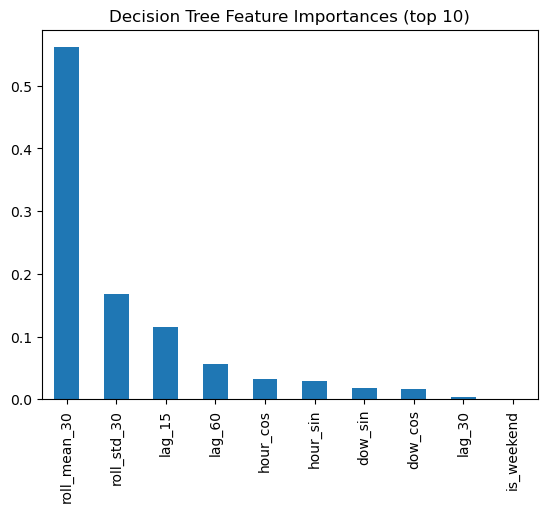

In [10]:
# ---- Explainability outputs (rules + importances) ----
tree_rules = export_text(best_res.model, feature_names=feature_cols, max_depth=4)  # print top levels only
print(tree_rules)

importances = pd.Series(best_res.model.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances)

# Optional quick plot of importances
plt.figure()
importances.head(10).plot(kind="bar")
plt.title("Decision Tree Feature Importances (top 10)")
plt.show()


### ETA prediction function (AC#1)

In production, you would:
1) take the most recent observation time **t**
2) compute features from history up to **t**
3) predict `P(congested at t+ETA)` and convert to Full/Available with a probability threshold.

Below is a simple helper that predicts for an existing row in the ML dataset (i.e., features already computed).  
This demonstrates the ETA logic end-to-end.



In [ ]:
def predict_full_available(
    model,
    X_row: pd.DataFrame,
    prob_threshold: float = 0.50,
) -> Dict[str, float]:
    """Return probability and binary class based on a probability threshold."""
    prob = float(model.predict_proba(X_row)[:, 1][0])
    pred = int(prob >= prob_threshold)
    return {"prob_congested": prob, "pred_congested": pred}

# Picks a random row from the *test* period and predict
sample = test_df.sample(1, random_state=RANDOM_STATE)
X_sample = sample[feature_cols]
out = predict_full_available(best_res.model, X_sample, prob_threshold=0.50)

print("Sample lot:", sample["lot_id"].iloc[0])
print("Sample time t:", sample["OccupancyDateTime"].iloc[0])
print("True y(t+ETA):", int(sample["y_t_plus_h"].iloc[0]))
print("Pred:", out)


Sample lot: Fremont
Sample time t: 2026-02-13 08:15:00
True y(t+ETA): 0
Pred: {'prob_congested': 0.16307070760766007, 'pred_congested': 0}


## Stronger models (Random Forest / XGBoost) - beyond current user-stories.

Decision Tree is the **primary baseline** (AC#3).  
These comparisons are useful for later sprints.

We also show why probability **thresholds** matter:
- default threshold 0.5
- more recall at a lower threshold (e.g., 0.3) at the expense of precision



In [18]:
from sklearn.ensemble import RandomForestClassifier

def eval_with_threshold(y_true: np.ndarray, y_prob: np.ndarray, thr: float) -> Dict[str, object]:
    y_pred = (y_prob >= thr).astype(int)
    rep = classification_report(y_true, y_pred, digits=4, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return {"thr": thr, "report": rep, "cm": cm}

X_train, y_train = train_df[feature_cols], train_df["y_t_plus_h"].astype(int)
X_test,  y_test  = test_df[feature_cols],  test_df["y_t_plus_h"].astype(int)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
print("RF AUC:", roc_auc_score(y_test, rf_prob))

for thr in [0.50, 0.30]:
    out = eval_with_threshold(y_test.values, rf_prob, thr)
    print(f"\n=== Random Forest threshold {thr:.2f} ===")
    print(out["report"])
    print("Confusion:\n", out["cm"])


from xgboost import XGBClassifier
xgb = XGBClassifier(
     n_estimators=400,
     max_depth=6,
     learning_rate=0.05,
     subsample=0.8,
     colsample_bytree=0.8,
     reg_lambda=1.0,
     random_state=RANDOM_STATE,
     eval_metric="logloss",
 )

xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print("XGB AUC:", roc_auc_score(y_test, xgb_prob))
for thr in [0.50, 0.30]:
    out = eval_with_threshold(y_test.values, xgb_prob, thr)
    print(f"\n=== XGB threshold {thr:.2f} ===")
    print(out["report"])
    print("Confusion:\n", out["cm"])


RF AUC: 0.8127408821908094

=== Random Forest threshold 0.50 ===
              precision    recall  f1-score   support

           0     0.9366    0.8068    0.8669     12001
           1     0.2946    0.5964    0.3944      1623

    accuracy                         0.7818     13624
   macro avg     0.6156    0.7016    0.6306     13624
weighted avg     0.8602    0.7818    0.8106     13624

Confusion:
 [[9683 2318]
 [ 655  968]]

=== Random Forest threshold 0.30 ===
              precision    recall  f1-score   support

           0     0.9641    0.6492    0.7759     12001
           1     0.2405    0.8213    0.3720      1623

    accuracy                         0.6697     13624
   macro avg     0.6023    0.7353    0.5740     13624
weighted avg     0.8779    0.6697    0.7278     13624

Confusion:
 [[7791 4210]
 [ 290 1333]]
XGB AUC: 0.8017963228880649

=== XGB threshold 0.50 ===
              precision    recall  f1-score   support

           0     0.9140    0.9656    0.9391     12001
